BAYESIAN COIN TOSS: 95% CENTRAL CREDIBLE INTERVAL
DATA SOURCE: data.txt (actual recorded flips)
TOTAL: 356 heads / 144 tails | PRIOR: Beta(2,5)


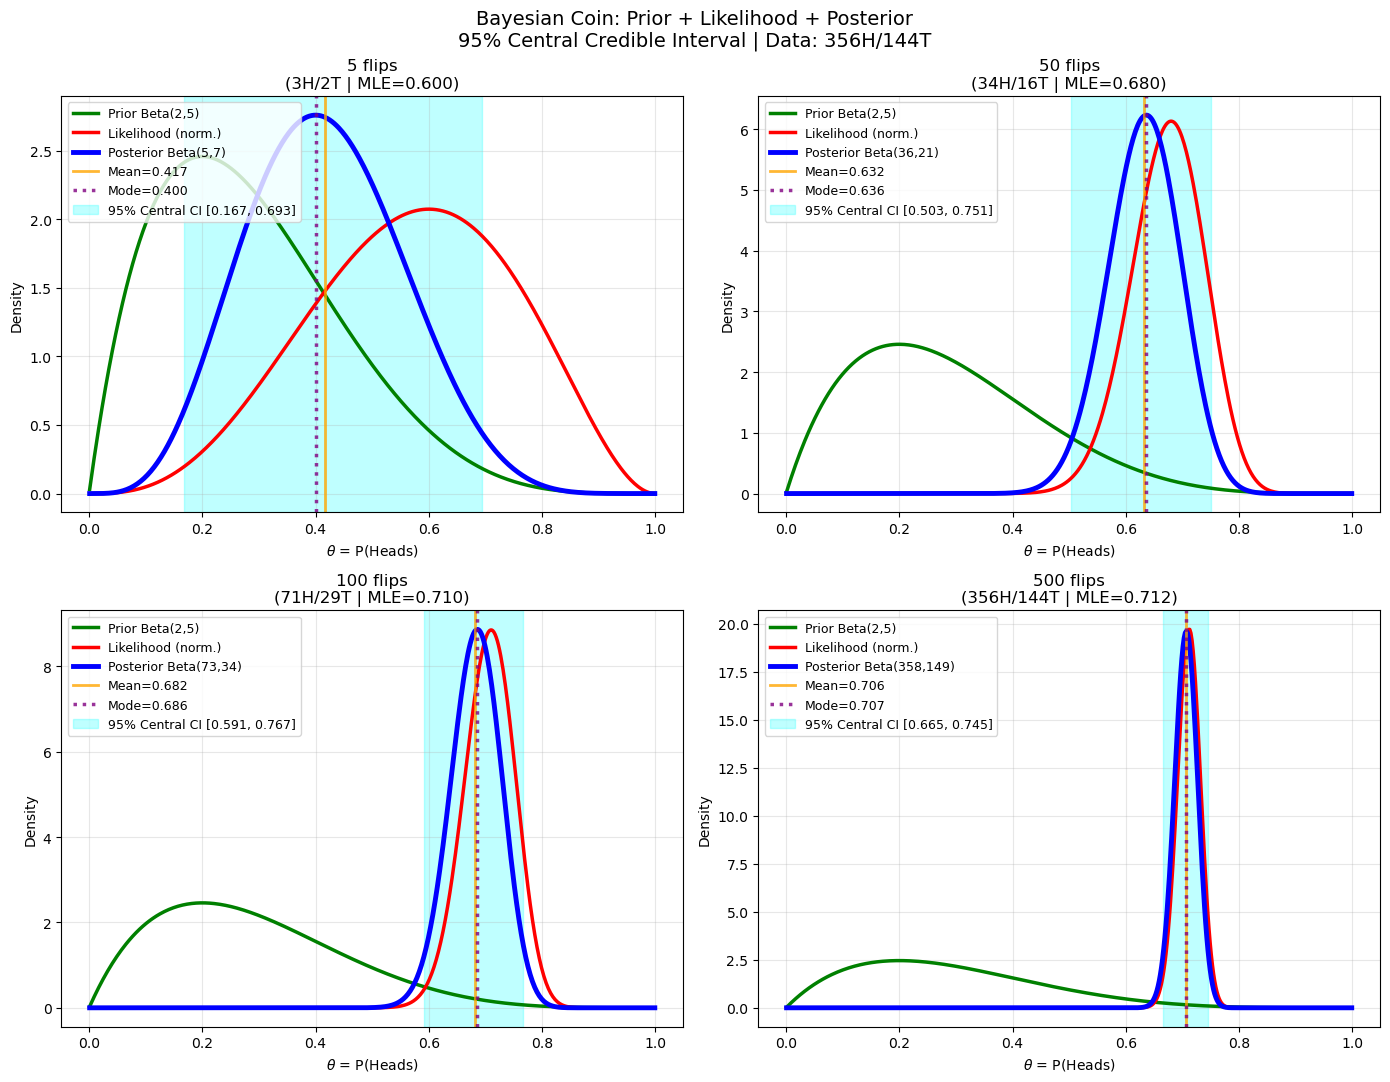


SUMMARY STATISTICS
    n heads tails             Posterior       Mean       Mode
------------------------------------------------------------------
    5     3     2            Beta(5,7):      0.417      0.400
   50    34    16          Beta(36,21):      0.632      0.636
  100    71    29          Beta(73,34):      0.682      0.686
  500   356   144        Beta(358,149):      0.706      0.707

Markdown Table:
|   n_trials |   heads |   tails |   mean |   mode |   MLE |
|-----------:|--------:|--------:|-------:|-------:|------:|
|          5 |       3 |       2 |  0.417 |  0.4   | 0.6   |
|         50 |      34 |      16 |  0.632 |  0.636 | 0.68  |
|        100 |      71 |      29 |  0.682 |  0.686 | 0.71  |
|        500 |     356 |     144 |  0.706 |  0.707 | 0.712 |

✓ SAVED: coin_central_ci_simple.png | coin_simple_stats.csv


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad, trapezoid

# =============================================================================
# BAYESIAN COIN: 95% CENTRAL CI + PERFECTLY ALIGNED TABLE
# Data loaded from actual data.txt (500 flips: 356 heads, 144 tails)
# =============================================================================

# Load actual coin-flip data from data.txt
data = np.loadtxt('data.txt', dtype=int)
n_total = len(data)
n_heads = int(np.sum(data))
n_tails = n_total - n_heads

print("=" * 60)
print("BAYESIAN COIN TOSS: 95% CENTRAL CREDIBLE INTERVAL")
print(f"DATA SOURCE: data.txt (actual recorded flips)")
print(f"TOTAL: {n_heads} heads / {n_tails} tails | PRIOR: Beta(2,5)")
print("=" * 60)

def beta_pdf_manual(theta, alpha, beta_param):
    if np.any(theta <= 0) or np.any(theta >= 1):
        return np.zeros_like(theta)
    num = theta**(alpha - 1) * (1 - theta)**(beta_param - 1)
    denom, _ = quad(lambda t: t**(alpha - 1) * (1 - t)**(beta_param - 1), 0, 1)
    return num / denom

def binom_likelihood(theta, n, h):
    return theta**h * (1 - theta)**(n - h)

def normalize_func(func_vals, theta_grid):
    integral = trapezoid(func_vals, theta_grid)
    return func_vals / integral if integral > 0 else func_vals


theta_grid = np.linspace(0.001, 0.999, 500)
n_trials_list = [5, 50, 100, n_total]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Bayesian Coin: Prior + Likelihood + Posterior\n'
             f'95% Central Credible Interval | Data: {n_heads}H/{n_tails}T', fontsize=14)

stats = []
for i, n_trials in enumerate(n_trials_list):
    ax = axes[i // 2, i % 2]

    h = int(np.sum(data[:n_trials])) if n_trials < n_total else n_heads
    t = n_trials - h

    alpha_post = 2 + h
    beta_post = 5 + t

    like_norm = normalize_func(binom_likelihood(theta_grid, n_trials, h), theta_grid)
    prior_vals = beta_pdf_manual(theta_grid, 2, 5)
    post_vals = beta_pdf_manual(theta_grid, alpha_post, beta_post)

    ax.plot(theta_grid, prior_vals, 'g-', linewidth=2.5, label='Prior Beta(2,5)')
    ax.plot(theta_grid, like_norm, 'r-', linewidth=2.5, label='Likelihood (norm.)')
    ax.plot(theta_grid, post_vals, 'b-', linewidth=3.5,
            label=f'Posterior Beta({alpha_post},{beta_post})')

    mean_post = alpha_post / (alpha_post + beta_post)
    mode_post = max(0, (alpha_post - 1) / (alpha_post + beta_post - 2))
    mle = h / n_trials

    # 95% CENTRAL CI (2.5% each tail)
    cum_norm = np.cumsum(post_vals) / np.sum(post_vals)
    ci_low_idx = np.searchsorted(cum_norm, 0.025)
    ci_high_idx = np.searchsorted(cum_norm, 0.975)
    ci_low = theta_grid[ci_low_idx]
    ci_high = theta_grid[ci_high_idx]

    ax.axvline(mean_post, color='orange', ls='-', alpha=0.8, linewidth=2,
               label=f'Mean={mean_post:.3f}')
    ax.axvline(mode_post, color='purple', ls=':', alpha=0.8, linewidth=2.5,
               label=f'Mode={mode_post:.3f}')
    ax.axvspan(ci_low, ci_high, alpha=0.25, color='cyan',
               label=f'95% Central CI [{ci_low:.3f}, {ci_high:.3f}]')

    ax.set_xlabel(r'$\theta$ = P(Heads)')
    ax.set_ylabel('Density')
    ax.set_title(f'{n_trials:,} flips\n({h}H/{t}T | MLE={mle:.3f})')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    stats.append([n_trials, h, t, mean_post, mode_post, mle])

plt.tight_layout()
plt.savefig('coin_central_ci_simple.png', dpi=150, bbox_inches='tight')
plt.show()

# PERFECTLY ALIGNED TABLE
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

max_n = max(row[0] for row in stats)
max_heads = max(row[1] for row in stats)
max_tails = max(row[2] for row in stats)
max_post_len = max(len(f"Beta({2 + row[1]},{5 + row[2]})") for row in stats)

w_n = len(str(max_n)) + 2
w_heads = len(str(max_heads)) + 2
w_tails = len(str(max_tails)) + 2
w_post = max_post_len + 8
w_mean = 10
w_mode = 10

def print_aligned_row(n_str, heads_str, tails_str, post_str, mean_str, mode_str):
    line = f"{n_str:>{w_n}} {heads_str:>{w_heads}} {tails_str:>{w_tails}} {post_str:>{w_post}} {mean_str:>{w_mean}} {mode_str:>{w_mode}}"
    print(line)

print_aligned_row('n', 'heads', 'tails', 'Posterior', 'Mean', 'Mode')
print('-' * (w_n + w_heads + w_tails + w_post + w_mean + w_mode + 10))

for row in stats:
    n, h, t, mean, mode, _ = row
    alpha_p = 2 + h; beta_p = 5 + t
    post_str = f"Beta({alpha_p},{beta_p}):"
    print_aligned_row(str(n), str(h), str(t), post_str, f"{mean:.3f}", f"{mode:.3f}")

df = pd.DataFrame(stats, columns=['n_trials', 'heads', 'tails', 'mean', 'mode', 'MLE'])
print(f"\nMarkdown Table:\n{df.round(3).to_markdown(index=False)}")
df.to_csv('coin_simple_stats.csv', index=False)
print("\n✓ SAVED: coin_central_ci_simple.png | coin_simple_stats.csv")
